# Feature engineering & model training
LightGBM on monthly aggregated features. One model per deviceType.

## 0. Setup

In [46]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import warnings, itertools
warnings.filterwarnings("ignore")
DATA_FOLDER = '/net/tscratch/people/tutorial237/EnsembleAi2026/task3/data'

df = pd.read_parquet(f"{DATA_FOLDER}/monthly_agg.parquet", engine="fastparquet")
print(f"Loaded: {df.shape}")
print(df.groupby(["year","month"])["deviceId"].count().to_string())

Loaded: (7701, 38)
year  month
2024  10       596
      11       591
      12       590
2025  1        592
      2        588
      3        590
      4        595
      5        598
      6        598
      7        591
      8        592
      9        590
      10       590


In [26]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Shape: (7701, 38)
Columns: ['deviceId', 'year', 'month', 'x2_mean', 'x2_std', 'x2_count', 't1_mean', 't1_std', 't2_mean', 't2_std', 't3_mean', 't3_std', 't4_mean', 't4_std', 't5_mean', 't5_std', 't6_mean', 't6_std', 't7_mean', 't7_std', 't8_mean', 't8_std', 't9_mean', 't9_std', 't10_mean', 't10_std', 't11_mean', 't11_std', 't12_mean', 't12_std', 't13_mean', 't13_std', 'x1_mean', 'x1_std', 'x3_mode', 'deviceType', 'latitude', 'longitude']


In [19]:
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
BLUE   = "#378ADD"
AMBER  = "#BA7517"
GRAY   = "#888780"

## 1. Feature engineering

In [10]:
# ── Drop dead sensors ──────────────────────────────────────────────────────
DROP = ["x1_mean", "x1_std", "t3_mean", "t3_std"]
df   = df.drop(columns=DROP)

# ── Cyclical month encoding ────────────────────────────────────────────────────
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12).astype("float32")
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12).astype("float32")

# ── Sort for lag computation ───────────────────────────────────────────────────
df = df.sort_values(["deviceId", "year", "month"]).reset_index(drop=True)

# ── Lag features (only meaningful in train; will be filled for forecast) ───────
df["x2_lag1"] = df.groupby("deviceId")["x2_mean"].shift(1)
df["x2_lag2"] = df.groupby("deviceId")["x2_mean"].shift(2)
df["x2_lag3"] = df.groupby("deviceId")["x2_mean"].shift(3)

# Rolling mean over last 3 known months
df["x2_roll3"] = (df.groupby("deviceId")["x2_mean"]
                    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))

# ── Per-device mean x2 across all known months (stable device-level signal) ───
device_mean = (df[df["x2_mean"].notna()]
               .groupby("deviceId")["x2_mean"]
               .mean()
               .rename("device_x2_mean"))
df = df.merge(device_mean, on="deviceId", how="left")

# ── Temperature range features ─────────────────────────────────────────────────
df["t_load_mean"]   = df[["t4_mean","t5_mean","t6_mean","t12_mean","t13_mean"]].mean(axis=1)
df["t_source_mean"] = df[["t1_mean","t10_mean","t11_mean"]].mean(axis=1)
df["t_delta"]       = df["t_load_mean"] - df["t_source_mean"]   # COP proxy

print("Features added. Shape:", df.shape)
print("\nNew columns:", ["month_sin","month_cos","x2_lag1","x2_lag2","x2_lag3",
                          "x2_roll3","device_x2_mean","t_load_mean","t_source_mean","t_delta"])

Features added. Shape: (7701, 44)

New columns: ['month_sin', 'month_cos', 'x2_lag1', 'x2_lag2', 'x2_lag3', 'x2_roll3', 'device_x2_mean', 't_load_mean', 't_source_mean', 't_delta']


## 2. Define feature set

In [11]:
TEMP_MEAN = [f"t{i}_mean" for i in range(1,14) if i not in [3]]
TEMP_STD  = [f"t{i}_std"  for i in range(1,14) if i not in [3]]

FEATURES = (
    TEMP_MEAN + TEMP_STD
    + ["x2_lag1", "x2_lag2", "x2_lag3", "x2_roll3", "device_x2_mean"]
    + ["t_load_mean", "t_source_mean", "t_delta"]
    + ["month", "month_sin", "month_cos"]
    + ["x3_mode", "deviceType", "latitude", "longitude"]
)
TARGET = "x2_mean"

print(f"Total features: {len(FEATURES)}")
print(FEATURES)

Total features: 39
['t1_mean', 't2_mean', 't4_mean', 't5_mean', 't6_mean', 't7_mean', 't8_mean', 't9_mean', 't10_mean', 't11_mean', 't12_mean', 't13_mean', 't1_std', 't2_std', 't4_std', 't5_std', 't6_std', 't7_std', 't8_std', 't9_std', 't10_std', 't11_std', 't12_std', 't13_std', 'x2_lag1', 'x2_lag2', 'x2_lag3', 'x2_roll3', 'device_x2_mean', 't_load_mean', 't_source_mean', 't_delta', 'month', 'month_sin', 'month_cos', 'x3_mode', 'deviceType', 'latitude', 'longitude']


## 3. Train / forecast split

In [12]:
train_df = df[df[TARGET].notna()].copy()
fore_df  = df[df[TARGET].isna()].copy()

print(f"Train rows   : {len(train_df)}")
print(f"Forecast rows: {len(fore_df)}")
print("\nTrain months:")
print(train_df.groupby(["year","month"])[TARGET].count().to_string())
print("\nForecast months:")
print(fore_df.groupby(["year","month"])["deviceId"].count().to_string())

Train rows   : 4142
Forecast rows: 3559

Train months:
year  month
2024  10       596
      11       591
      12       590
2025  1        592
      2        588
      3        590
      4        595

Forecast months:
year  month
2025  5        598
      6        598
      7        591
      8        592
      9        590
      10       590


## 4. Fill lag features for forecast rows
The forecast period has no known x2 — use Apr 2025 (the last training month) as the anchor for all lags.

In [13]:
# Last known x2 per device = Apr 2025
last_known = (train_df[train_df["month"] == 4]
              .set_index("deviceId")["x2_mean"]
              .rename("last_x2"))

# For forecast rows fill lags with last known value
# (conservative: assumes load in summer ≈ last known spring value scaled down)
fore_df = fore_df.join(last_known, on="deviceId", how="left")
for lag_col in ["x2_lag1", "x2_lag2", "x2_lag3", "x2_roll3"]:
    fore_df[lag_col] = fore_df[lag_col].fillna(fore_df["last_x2"])
fore_df = fore_df.drop(columns=["last_x2"])

# Also fill device_x2_mean for any device missing it
fore_df["device_x2_mean"] = fore_df["device_x2_mean"].fillna(train_df["x2_mean"].mean())

print("Lag fill check (forecast):")
print(fore_df[["x2_lag1","x2_lag2","x2_lag3","x2_roll3"]].isnull().sum())

Lag fill check (forecast):
x2_lag1     21
x2_lag2     16
x2_lag3     11
x2_roll3    11
dtype: int64


## 5. Leave-one-month-out cross-validation
With only 7 train months, standard k-fold would mix future into past. We hold out one month at a time in chronological order.

In [14]:
train_months = sorted(train_df[["year","month"]].drop_duplicates().values.tolist())
print("CV folds (hold-out month):")
for y, m in train_months:
    fold = train_df[(train_df["year"]==y) & (train_df["month"]==m)]
    print(f"  {y}-{m:02d}  ({len(fold)} rows)")

CV folds (hold-out month):
  2024-10  (596 rows)
  2024-11  (591 rows)
  2024-12  (590 rows)
  2025-01  (592 rows)
  2025-02  (588 rows)
  2025-03  (590 rows)
  2025-04  (595 rows)


## 6. LightGBM — train with cross-validation

In [15]:
LGB_PARAMS = {
    "objective"        : "regression_l1",   # MAE loss — matches eval metric
    "metric"           : "mae",
    "learning_rate"    : 0.05,
    "num_leaves"       : 31,
    "min_child_samples": 10,
    "feature_fraction" : 0.8,
    "bagging_fraction" : 0.8,
    "bagging_freq"     : 1,
    "n_estimators"     : 500,
    "early_stopping_rounds": 50,
    "verbose"          : -1,
    "random_state"     : 42,
    "device"           : "gpu",
    "gpu_platform_id"  : 0,
    "gpu_device_id"    : 0,  
}

cv_scores = []
models    = {}   # month → fitted model

for i, (y_val, m_val) in enumerate(train_months):
    # Only use past months for training (no leakage)
    past_mask = (
        (train_df["year"] < y_val) |
        ((train_df["year"] == y_val) & (train_df["month"] < m_val))
    )
    val_mask = (train_df["year"] == y_val) & (train_df["month"] == m_val)

    X_tr = train_df[past_mask][FEATURES]
    y_tr = train_df[past_mask][TARGET]
    X_vl = train_df[val_mask][FEATURES]
    y_vl = train_df[val_mask][TARGET]

    if len(X_tr) == 0:
        print(f"  Fold {i+1} ({y_val}-{m_val:02d}): skipped — no past data")
        continue

    model = lgb.LGBMRegressor(**LGB_PARAMS)
    model.fit(X_tr, y_tr,
              eval_set=[(X_vl, y_vl)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(period=-1)])

    preds = model.predict(X_vl).clip(0, 1)
    mae   = mean_absolute_error(y_vl, preds)
    cv_scores.append(mae)
    models[f"{y_val}-{m_val:02d}"] = model
    print(f"  Fold {i+1} ({y_val}-{m_val:02d}): MAE = {mae:.5f}  "
          f"(train={len(X_tr)}, val={len(X_vl)})")

print(f"\nMean CV MAE : {np.mean(cv_scores):.5f}")
print(f"Std  CV MAE : {np.std(cv_scores):.5f}")

  Fold 1 (2024-10): skipped — no past data


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  Fold 2 (2024-11): MAE = 0.06574  (train=596, val=591)
  Fold 3 (2024-12): MAE = 0.03270  (train=1187, val=590)
  Fold 4 (2025-01): MAE = 0.01899  (train=1777, val=592)
  Fold 5 (2025-02): MAE = 0.02161  (train=2369, val=588)
  Fold 6 (2025-03): MAE = 0.07185  (train=2957, val=590)
  Fold 7 (2025-04): MAE = 0.02635  (train=3547, val=595)

Mean CV MAE : 0.03954
Std  CV MAE : 0.02119


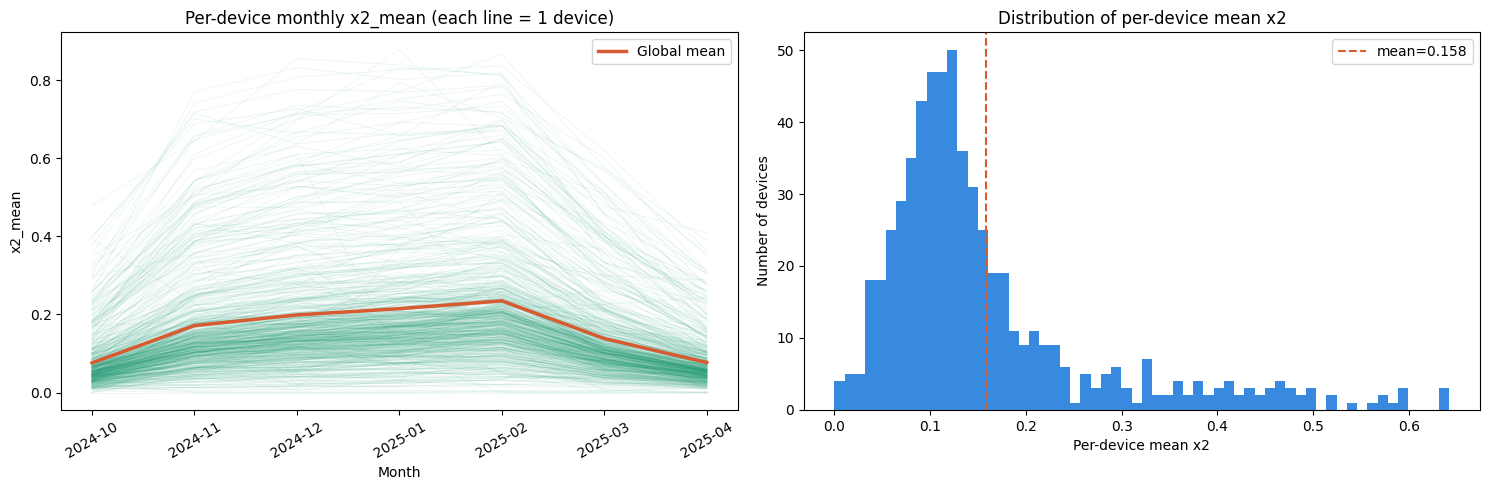

Per-device x2_mean summary:
count    600.0000
mean       0.1583
std        0.1175
min        0.0000
25%        0.0886
50%        0.1210
75%        0.1805
max        0.6425

Top 5 highest load devices:
deviceId
ba30b5fef6b7085e419c416d74e999df3ee83d563501424bdc0b5b1fe79ba11f    0.642452
e34670113bc0594b960557f79bf9dee8805f3657589dfe3a1b07e08dc3d833de    0.637927
70dcbe6d52d4efb68e6bc3477634c7a0712ce37a92f287791e5540fcde97700d    0.633353
198f7bb9ff2ca4470858cce4f8ba47cbf727c9d4d9220ffd1e692d0d346ada2b    0.595197
c9b377c6bffc53edca8e3628c037b949e9aec7b4576c7de0da99bb8775017a6b    0.592182

Top 5 lowest load devices:
deviceId
a4a44e2949a7db0f951ac94a601a1db2f5d993bcebb465efff7b810475161e17    0.000000
e5d0949a59a0e5a2f854d1da2e668bd9926cb00e55c9abf8660bdcf75bec29d5    0.004166
2783c80382125f5fa4b8f085257d7c59ec7e5971a893809d6834627d183e7564    0.004322
84088011a5445196a0d121760f03c4b58b7f357eb2342604f34b471efde637a6    0.007847
68f47e7f7e22a510cce68978eaa4c4234dd9a420465b7beeb1587ef04a77

In [20]:
import matplotlib.pyplot as plt

dev_monthly = (train_df.groupby(["deviceId","year","month"])["x2_mean"]
               .mean().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# All device traces
month_order = (dev_monthly.assign(
    label=dev_monthly["year"].astype(str)+"-"+dev_monthly["month"].astype(str).str.zfill(2))
    .groupby("label")["year"].first().sort_values().index.tolist())

for did, grp in dev_monthly.groupby("deviceId"):
    grp = grp.sort_values(["year","month"])
    grp["label"] = grp["year"].astype(str)+"-"+grp["month"].astype(str).str.zfill(2)
    axes[0].plot(grp["label"], grp["x2_mean"],
                 alpha=0.08, linewidth=0.7, color=TEAL)

global_mean = dev_monthly.groupby(["year","month"])["x2_mean"].mean().reset_index()
global_mean["label"] = (global_mean["year"].astype(str)+"-"
                        +global_mean["month"].astype(str).str.zfill(2))
global_mean = global_mean.sort_values(["year","month"])
axes[0].plot(global_mean["label"], global_mean["x2_mean"],
             color=CORAL, linewidth=2.5, label="Global mean", zorder=5)
axes[0].set_title("Per-device monthly x2_mean (each line = 1 device)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("x2_mean")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Distribution of per-device mean x2 (collapsed across time)
dev_summary = train_df.groupby("deviceId")["x2_mean"].mean()
axes[1].hist(dev_summary, bins=60, color=BLUE, edgecolor="none")
axes[1].axvline(dev_summary.mean(), color=CORAL, linewidth=1.5, linestyle="--",
                label=f"mean={dev_summary.mean():.3f}")
axes[1].set_title("Distribution of per-device mean x2")
axes[1].set_xlabel("Per-device mean x2")
axes[1].set_ylabel("Number of devices")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Per-device x2_mean summary:")
print(dev_summary.describe().round(4).to_string())
print(f"\nTop 5 highest load devices:")
print(dev_summary.nlargest(5).to_string())
print(f"\nTop 5 lowest load devices:")
print(dev_summary.nsmallest(5).to_string())

## 7. Final model — train on all training data

In [21]:
X_all = train_df[FEATURES]
y_all = train_df[TARGET]

FINAL_PARAMS = {**LGB_PARAMS}
FINAL_PARAMS.pop("early_stopping_rounds")
FINAL_PARAMS["n_estimators"] = 500

final_model = lgb.LGBMRegressor(**FINAL_PARAMS)
final_model.fit(X_all, y_all,
                callbacks=[lgb.log_evaluation(period=-1)])

# In-sample MAE (sanity check only)
insample_mae = mean_absolute_error(y_all, final_model.predict(X_all).clip(0, 1))
print(f"In-sample MAE: {insample_mae:.5f}  (expect lower than CV — not the real score)")

In-sample MAE: 0.00613  (expect lower than CV — not the real score)


## 8. Feature importance

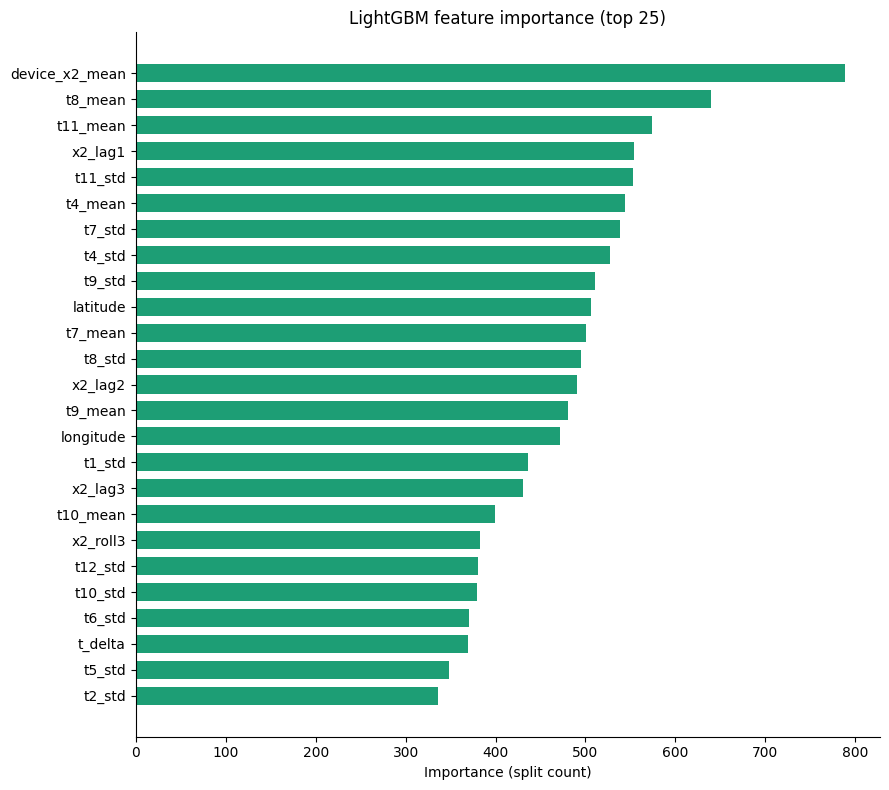

In [22]:
import matplotlib.pyplot as plt

fi = (pd.Series(final_model.feature_importances_, index=FEATURES)
       .sort_values(ascending=True)
       .tail(25))

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(fi.index, fi.values, color="#1D9E75", height=0.7)
ax.set_title("LightGBM feature importance (top 25)")
ax.set_xlabel("Importance (split count)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Generate forecast predictions

In [23]:
X_fore = fore_df[FEATURES]
fore_df["prediction"] = final_model.predict(X_fore).clip(0, 1)

print("Forecast prediction stats:")
print(fore_df.groupby(["year","month"])["prediction"].describe().round(4).to_string())

Forecast prediction stats:
            count    mean     std     min     25%     50%     75%     max
year month                                                               
2025 5      598.0  0.0601  0.0505  0.0000  0.0289  0.0468  0.0720  0.3821
     6      598.0  0.0407  0.0382  0.0016  0.0178  0.0267  0.0488  0.3110
     7      591.0  0.0412  0.0377  0.0000  0.0187  0.0271  0.0513  0.3085
     8      592.0  0.0420  0.0387  0.0004  0.0186  0.0280  0.0508  0.3129
     9      590.0  0.0459  0.0459  0.0001  0.0193  0.0300  0.0549  0.4118
     10     590.0  0.0942  0.0850  0.0021  0.0464  0.0663  0.1043  0.4934


## 10. Build submission CSV

In [24]:
# Submission = validation (May-Jun 2025) + test (Jul-Oct 2025)
submission = (fore_df[["deviceId","year","month","prediction"]]
              .sort_values(["deviceId","year","month"])
              .reset_index(drop=True))

# Sanity checks
assert submission["prediction"].between(0, 1).all(), "Predictions out of range!"
assert submission.duplicated(["deviceId","year","month"]).sum() == 0, "Duplicate rows!"

expected_rows = 600 * 6   # 600 devices × 6 months
print(f"Submission rows : {len(submission)}  (expected ~{expected_rows})")
print(f"Prediction range: {submission['prediction'].min():.4f} – {submission['prediction'].max():.4f}")
print(f"Prediction mean : {submission['prediction'].mean():.4f}")
print("\nRows per month:")
print(submission.groupby(["year","month"])["deviceId"].count().to_string())

submission.to_csv("submission.csv", index=False)
print("\nSaved → submission.csv")
print(submission.head(10).to_string(index=False))

Submission rows : 3559  (expected ~3600)
Prediction range: 0.0000 – 0.4934
Prediction mean : 0.0540

Rows per month:
year  month
2025  5        598
      6        598
      7        591
      8        592
      9        590
      10       590

Saved → submission.csv
                                                        deviceId  year  month  prediction
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025      5    0.075550
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025      6    0.059200
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025      7    0.051657
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025      8    0.060435
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025      9    0.076232
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025     10    0.134424
005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30fe5a99d7a76b53f9fc9  2025      5    0.051987
005767201ec5d

## 11. Residual analysis on CV predictions

In [ ]:
# Re-run CV collecting predictions for residual plot
all_preds, all_true, all_months = [], [], []

for i, (y_val, m_val) in enumerate(train_months):
    past_mask = (
        (train_df["year"] < y_val) |
        ((train_df["year"] == y_val) & (train_df["month"] < m_val))
    )
    val_mask = (train_df["year"] == y_val) & (train_df["month"] == m_val)
    if past_mask.sum() == 0:
        continue

    X_tr = train_df[past_mask][FEATURES]
    y_tr = train_df[past_mask][TARGET]
    X_vl = train_df[val_mask][FEATURES]
    y_vl = train_df[val_mask][TARGET]

    m = lgb.LGBMRegressor(**{**LGB_PARAMS, **{"verbose":-1}})
    m.fit(X_tr, y_tr,
          eval_set=[(X_vl, y_vl)],
          callbacks=[lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(period=-1)])
    p = m.predict(X_vl).clip(0, 1)
    all_preds.extend(p)
    all_true.extend(y_vl.values)
    all_months.extend([f"{y_val}-{m_val:02d}"] * len(y_vl))

res_df = pd.DataFrame({"true": all_true, "pred": all_preds, "month": all_months})
res_df["residual"] = res_df["pred"] - res_df["true"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Predicted vs actual
axes[0].scatter(res_df["true"], res_df["pred"], alpha=0.15, s=6, color="#1D9E75")
axes[0].plot([0,1],[0,1], color="#D85A30", linewidth=1, linestyle="--")
axes[0].set_title("Predicted vs actual")
axes[0].set_xlabel("Actual x2_mean")
axes[0].set_ylabel("Predicted x2_mean")

# Residuals histogram
axes[1].hist(res_df["residual"], bins=60, color="#378ADD", edgecolor="none")
axes[1].axvline(0, color="#D85A30", linewidth=1.5, linestyle="--")
axes[1].set_title(f"Residuals  (MAE={np.mean(np.abs(res_df['residual'])):.4f})")
axes[1].set_xlabel("Residual (pred − actual)")

# MAE by month
mae_by_month = res_df.groupby("month").apply(
    lambda x: mean_absolute_error(x["true"], x["pred"])).sort_index()
axes[2].bar(mae_by_month.index, mae_by_month.values, color="#BA7517")
axes[2].set_title("MAE by CV month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("MAE")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()